In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os, h5py, time, psutil

import numpy as np
import healpy as hp
import tensorflow as tf

from tqdm import tqdm, trange
from sklearn.neighbors import BallTree

# from deepsphere.utils import split_sparse_dense_matmul
from deep_lss.utils import layers

from msfm.grid_pipeline import GridPipeline

23-11-02 09:10:06   imports.py INF   Setting up healpy to run on 256 CPUs 
23-11-02 09:10:06   imports.py INF   Setting up healpy to run on 256 CPUs 


# constants

In [27]:
sigma_arcmin = 10
n_sigma_support = 3
sigma_rad = sigma_arcmin / 60 / 180 * np.pi

# example map

In [28]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/tfrecords/grid/DESy3_grid_000.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml"
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

grid_pipe = GridPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=False,
    with_padding=True,
    apply_norm=False
)

dv_pix = grid_pipe.data_vec_pix
n_dv_pix = len(dv_pix)

n_side = 512
n_pix = hp.nside2npix(n_side)

n_channels = grid_pipe.n_z_metacal# + grid_pipe.n_z_maglim
n_noise = 3

batch_size = 32

dset = grid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        n_noise=n_noise,
        local_batch_size=batch_size,
        n_readers=1,
        n_prefetch=0,
)

for dv, cosmo, index in dset.take(1):
    pass

print(dv.shape)

23-11-02 09:24:20     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-02 09:24:20     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-02 09:24:20 grid_pipelin INF   Interleaving with n_readers = 1 
23-11-02 09:24:20 grid_pipelin INF   Batching into 32 elements locally 
23-11-02 09:24:20 grid_pipelin WAR   Tracing _augmentations 
23-11-02 09:24:20 grid_pipelin INF   Running on the data_vectors.keys() = dict_keys(['cosmo', 'i_sobol', 'i_example', 'kg', 'i_noise']) 
23-11-02 09:24:20 grid_pipelin INF   Successfully generated the fiducial training set with element_spec (TensorSpec(shape=(None, 464896, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None), (TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.i

In [46]:
smoothing_layer = layers.HealpixSmoothingLayer(
    n_side=n_side, 
    indices=dv_pix,
    sigma=sigma_arcmin,
    data_path="/pscratch/sd/a/athomsen/debug/smoothing_kernel",
    per_channel_repetitions=[3,3,3,3]
)

23-11-02 09:27:11    layers.py INF   Successfully loaded sparse kernel indices and values from /pscratch/sd/a/athomsen/debug/smoothing_kernel 
23-11-02 09:27:14    layers.py INF   Successfully created the sparse kernel tensor 


In [50]:
%%time
dv_smooth = smoothing_layer(dv)

CPU times: user 745 ms, sys: 1.74 s, total: 2.49 s
Wall time: 2.49 s


In [38]:
# %%time

# for _ in range(100):
#     smoothing_layer(dv)

In [39]:
# n_matmul_splits = 1
# while not (
#     # tf.split only does even splits for integer arguments
#     (max_batch_size * current_Fin % n_matmul_splits == 0) and 
#     # due to tf.sparse.sparse_dense_matmul
#     (n_matmul_splits >= max_batch_size * current_Fin * len(current_L.indices) / 2**31)
# ):
#     n_matmul_splits += 1


# plotting

In [40]:
i_batch = 0
i_channel = 0

### healpy

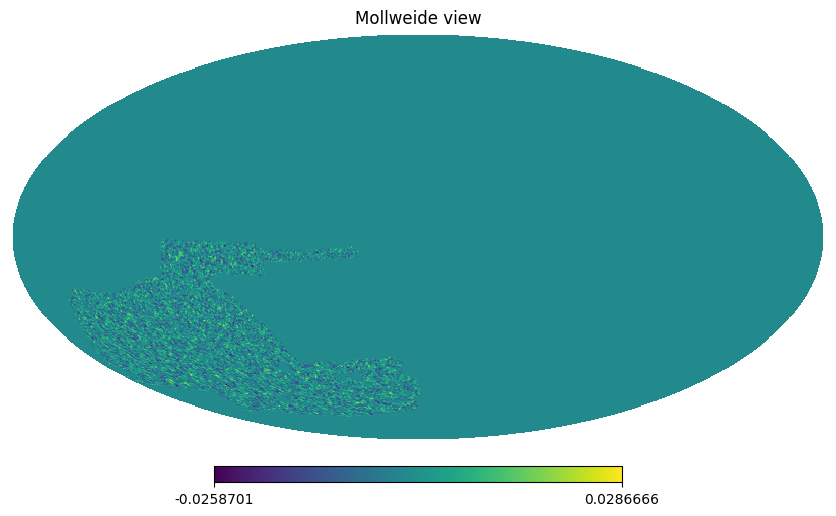

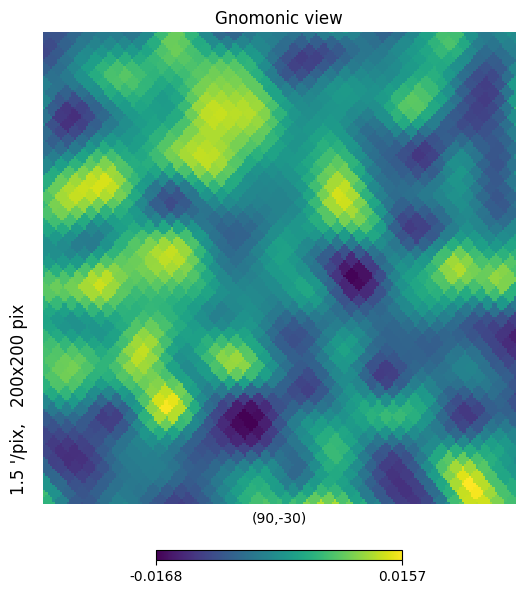

In [41]:
hp_map = np.zeros(n_pix)
hp_map[dv_pix] = dv[i_batch,:,1]
hp_map = hp.reorder(hp_map, n2r=True)

hp_smooth = hp.sphtfunc.smoothing(hp_map, sigma=sigma_rad)

hp.mollview(hp_smooth)
hp.gnomview(hp_smooth, rot=(90, -30, 0))

### tensorflow

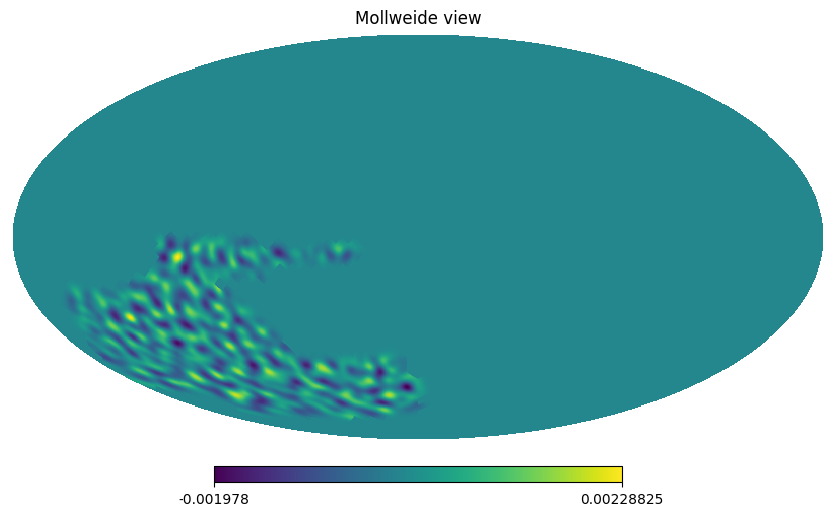

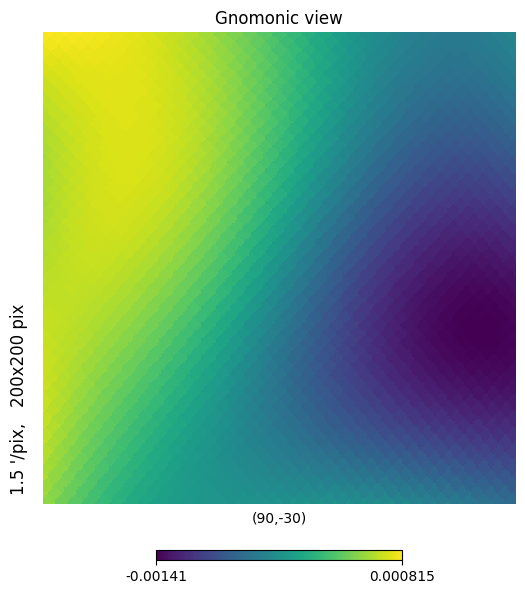

In [51]:
tf_smooth = np.zeros(n_pix)
tf_smooth[dv_pix] = dv_smooth[i_batch,:,1].numpy()

hp.mollview(tf_smooth, nest=True)
hp.gnomview(tf_smooth, rot=(90, -30, 0), nest=True)

vmin = tf_smooth.min()
vmax = tf_smooth.max()

### difference

In [ ]:
diff_smooth = hp.reorder(hp_smooth, r2n=True) - tf_smooth

hp.mollview(diff_smooth, nest=True, min=vmin, max=vmax)
hp.gnomview(diff_smooth, rot=(90, -30, 0), nest=True, min=vmin, max=vmax)

# hp.mollview(diff_smooth, nest=True)
# hp.gnomview(diff_smooth, rot=(90, -30, 0), nest=True)